# 放物線運動の離散化による計算
---
## 初期条件
- 初期位置
$$
    (x,y) = (0, 0)
$$
- 初速度
$$
    (v_x,v_y) = (v_{0x}, v_0)
$$  

---
## $x$方向(等速運動)

$$
    v_x = v_x
$$
$$
    x_n = n \, v_x \Delta t
$$

---
## $y$方向(等加速度運動)
$$
    v_n = v_0 - \sum_{k=0}^{n-1}g \Delta t = v_0 - n \Delta t
$$
$$
    y_n = \sum_{k=0}^{n-1}v_k \Delta t = n v_0 \Delta t - \frac{n(n-1)}{2} g (\Delta t)^2
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# パラメータ
v_0x = 10.0
v_0 = 10.0
t = 0.05
g = 9.8

# ステップ数（n）
steps = np.arange(0, 1000)

# 関数定義
def cal_x(n):
    return n * v_0x * t

def cal_y_numerical(n):
    return n * v_0 * t - 0.5 * n * (n - 1) * g * (t**2)

def cal_y_analytical(n):
    return n * v_0 * t - 0.5 * g * (n * t)**2

# 計算
x = cal_x(steps)
y_num = cal_y_numerical(steps)
y_ana = cal_y_analytical(steps)

# y > 0を抽出
tol = -0.5
x_ex = x[y_ana > tol] 
y_num_ex = y_num[y_ana > tol]
y_ana_ex = y_ana[y_ana > tol]

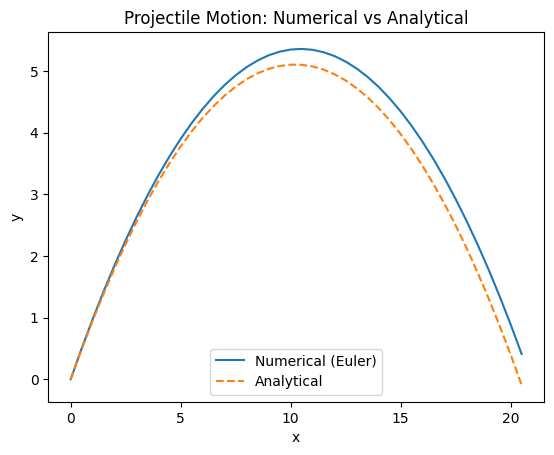

In [3]:
# プロット
plt.figure()
plt.plot(x_ex, y_num_ex, label="Numerical (Euler)")
plt.plot(x_ex, y_ana_ex, linestyle="--", label="Analytical")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Projectile Motion: Numerical vs Analytical")
plt.show()